In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

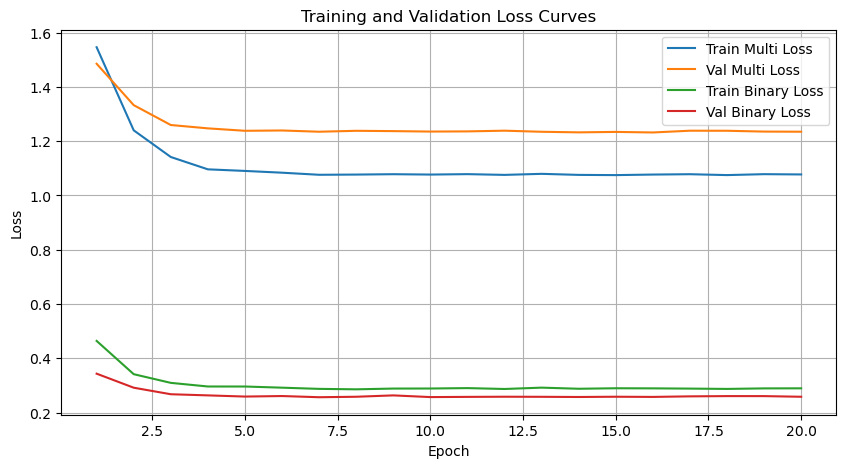

In [8]:
import json
import os
import matplotlib.pyplot as plt

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Load metrics
with open("metrics.json", "r") as f:
    metrics = json.load(f)

epochs = range(1, len(metrics["val_loss_multi"]) + 1)

plt.figure(figsize=(10,5))

# Multi-class loss
plt.plot(epochs, metrics["train_loss_multi"], label="Train Multi Loss")
plt.plot(epochs, metrics["val_loss_multi"], label="Val Multi Loss")

# Binary loss
plt.plot(epochs, metrics["train_loss_binary"], label="Train Binary Loss")
plt.plot(epochs, metrics["val_loss_binary"], label="Val Binary Loss")

plt.title("Training and Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.savefig(os.path.join(RESULTS_DIR, "loss_curves.png"), dpi=300)
plt.show()

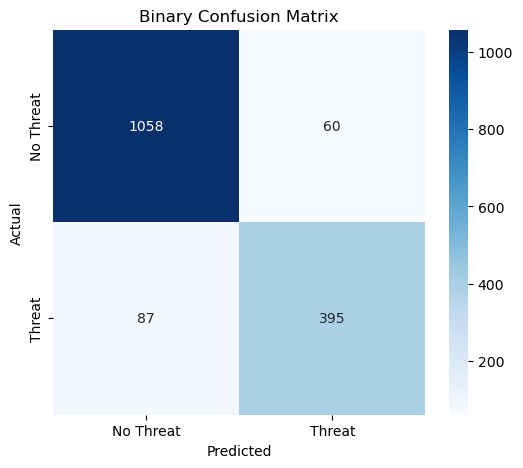

In [5]:
cm_binary = np.load("confusion_matrix_binary.npy")

plt.figure(figsize=(6,5))
sns.heatmap(cm_binary, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Threat", "Threat"],
            yticklabels=["No Threat", "Threat"])

plt.title("Binary Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# plt.savefig("binary_confusion_matrix.png", dpi=300)
plt.savefig(os.path.join(RESULTS_DIR, "binary_confusion_matrix.png"), dpi=300)
plt.show()

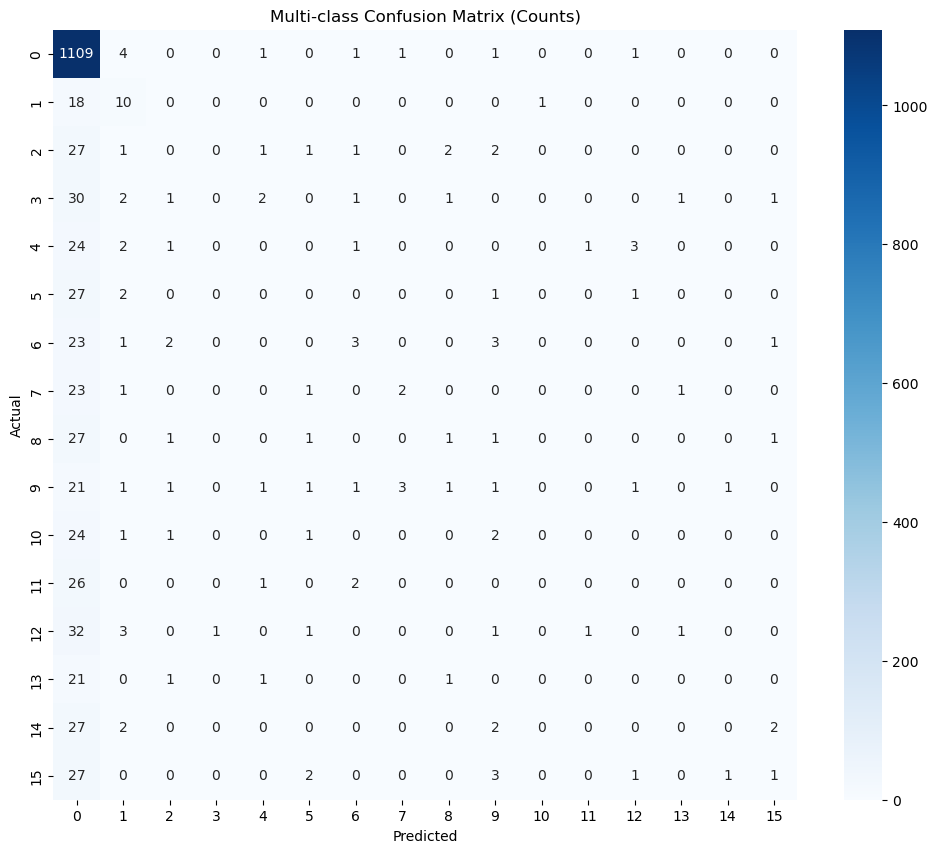

In [6]:

cm_multi = np.load("confusion_matrix_multi.npy")

plt.figure(figsize=(12,10))
sns.heatmap(
    cm_multi,
    annot=True,      
    fmt="d", 
    cmap="Blues",        
)

plt.title("Multi-class Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(os.path.join(RESULTS_DIR, "multiclass_confusion_matrix_counts.png"), dpi=300)
plt.show()

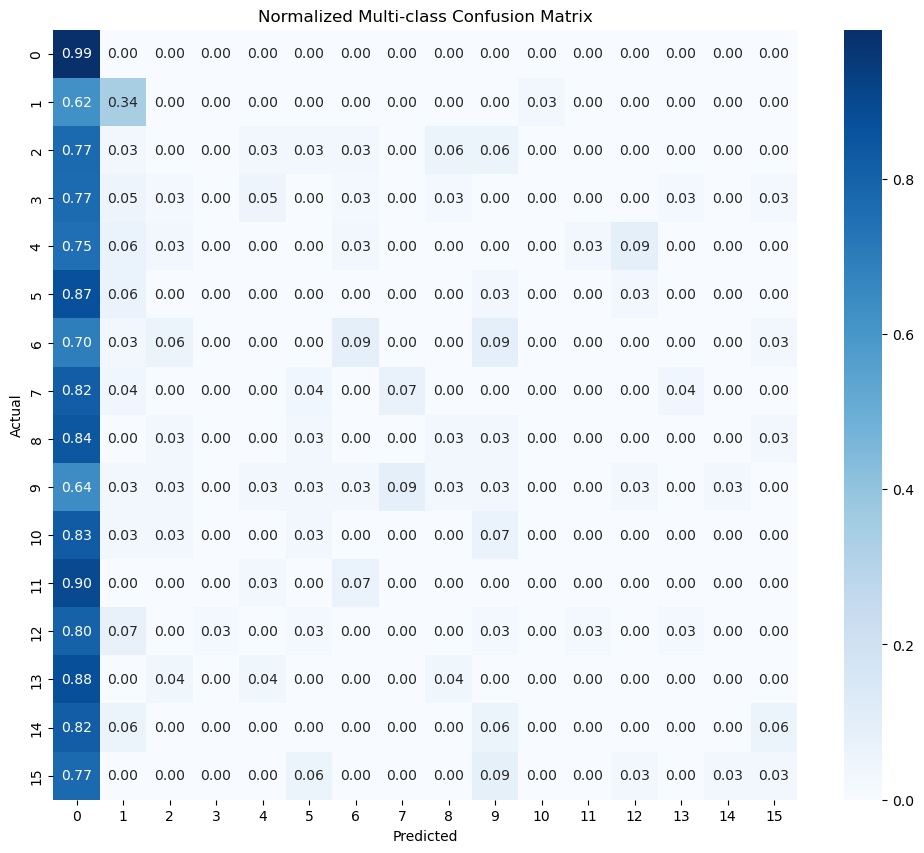

In [7]:
cm_multi = np.load("confusion_matrix_multi.npy")

# Normalize
cm_norm = cm_multi.astype('float') / cm_multi.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12,10))
sns.heatmap(
    cm_norm,
    annot=True,          
    fmt=".2f",          
    cmap="Blues",
    cbar=True
)

plt.title("Normalized Multi-class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# plt.savefig("multiclass_confusion_matrix_numbers.png", dpi=300)
plt.savefig(os.path.join(RESULTS_DIR, "multiclass_confusion_matrix_percentage.png"), dpi=300)
plt.show()